# ALM multi-étapes pour un fonds de pension canadien — Phases 1 à 6

**Travail dirigé — M. Sc. Finance mathématique et computationnelle (UdeM)**
Référence : Klein Haneveld, van der Vlerk & Romeijnders (2020), chap. 1–3 (recours), chap. 6 (ICC, CSaR).

Programme linéaire de recours multi-étapes sur arbre de scénarios. Actif fermé (cotisation initiale seulement), passif actuariel exogène, surplus signé $S_t = A_t - L_t$, objectif terminal $-\mathbb{E}[S_T] - \lambda\,\mathrm{CSaR}_\gamma(S_T)$, solvabilité intermédiaire par ICC inconditionnelles.

**Univers** : cinq ETF cotés au TSX — XIC (actions CA), VFV (actions US, S&P 500), XLB (obligations long terme), XRB (obligations à rendement réel), CGL (or, lingots, couvert CAD — diversificateur satellite). La poche VFV est détenue **non couverte** (pratique répandue chez les caisses canadiennes ; le CAD procyclique amortit les drawdowns en CAD) : le risque de change est **modélisé implicitement** via les rendements en CAD — cf. la cellule diagnostique VFV/VSP en phase 1. CGL reste couvert par construction. Génération GBM, branchement **10 à la première période puis 5** ($T=5$).

**Données** : téléchargement direct du cours ajusté mensuel via `YFinance.jl` (API Yahoo gratuite, sans clé).

**Exécution** : lancer les cellules dans l'ordre (« Run All »). La cellule de packages installe `YFinance`, `Plots` et `StatsPlots` au besoin.


In [1]:
# === Packages (installation au besoin) ===
import Pkg
for pkg in ("JuMP", "HiGHS", "YFinance", "Distributions", "DataFrames", "Plots", "StatsPlots")
    try
        @eval using $(Symbol(pkg))
    catch
        Pkg.add(pkg); @eval using $(Symbol(pkg))
    end
end
using LinearAlgebra, Random, Statistics, Printf, Dates

const MOI = JuMP.MOI
gr()
println("Packages chargés.")


Packages chargés.


## Phase 1 — Configuration, téléchargement et calibration

On télécharge le cours ajusté (total-return) mensuel des cinq ETF, on aligne les séries sur leurs mois communs, puis on estime $(\mu_a, \Sigma_a)$ sur les log-rendements annualisés. L'estimation portant sur les log-rendements, $\hat\mu_a$ est déjà le drift GBM (terme $-\sigma^2/2$ inclus) : pas de re-correction d'Itô. On vérifie que $\hat\Sigma_a$ est définie positive et on inspecte les blocs corrélés (obligataire XLB↔XRB, actions XIC↔VFV) ainsi que l'orthogonalité de l'or.


In [2]:
# === Configuration globale ===
const TICKERS  = ["XIC.TO", "XLB.TO", "XRB.TO", "VFV.TO", "CGL.TO"]
const ASSETS   = ["XIC", "XLB", "XRB", "VFV", "CGL"]
const ALABELS  = ["XIC (actions CA)", "XLB (oblig. LT)", "XRB (oblig. réel)",
                  "VFV (actions US)", "CGL (or)"]
const NA       = length(ASSETS)
const START    = "2005-01-01"
const STOP     = "2026-06-30"   # date de fin FIGÉE (reproductibilité — ne pas remettre today())

const BRANCHES = [10, 5, 5, 5, 5]      # 10 nœuds à la 1re période, 5 ensuite
const T        = length(BRANCHES)
const GAMMA    = 0.95

# Bornes d'allocation (ordre XIC, XLB, XRB, VFV, CGL). Or = satellite (0–10 %).
const W_LOWER = [0.05, 0.15, 0.05, 0.05, 0.00]
const W_UPPER = [0.40, 0.60, 0.40, 0.40, 0.10]
@assert sum(W_LOWER) <= 1 && sum(W_UPPER) >= 1 "Bornes infaisables : sum(lower)<=1<=sum(upper) requis."

const PHI = collect(range(0.02, 0.04, length=T))   # F_t = phi_t * E[L_t], périodes 0..T-1

const A0 = 100.0
const L0 = 100.0
const G_MEAN = 0.03
const G_SD   = 0.02

@printf("Univers : %s\n", join(ASSETS, ", "))
@printf("Branchement : %s  =>  %d feuilles, queue 5%% ≈ %d feuilles\n",
        string(BRANCHES), prod(BRANCHES), round(Int, 0.05*prod(BRANCHES)))


Univers : XIC, XLB, XRB, VFV, CGL
Branchement : [10, 5, 5, 5, 5]  =>  6250 feuilles, queue 5% ≈ 312 feuilles


In [3]:
# === Téléchargement + calibration ===
"Projection sur le cône des matrices définies positives (clip des valeurs propres)."
function make_posdef(S; eps=1e-10)
    M = Symmetric(Matrix(S))
    isposdef(M) && return Matrix(M)
    E = eigen(M)
    R = E.vectors * Diagonal(max.(E.values, eps)) * E.vectors'
    return Matrix(Symmetric((R + R') / 2))
end

"Cours ajusté mensuel des tickers, aligné sur les mois communs. Renvoie (dates, matrice prix)."
function download_adjclose(tickers; start, stop)
    maps = Dict{String,Dict{Date,Float64}}()
    for tk in tickers
        d   = get_prices(tk; startdt=start, enddt=stop, interval="1mo")
        dts = Dates.firstdayofmonth.(Date.(d["timestamp"]))
        maps[tk] = Dict(zip(dts, Float64.(d["adjclose"])))
    end
    common = sort(collect(reduce(intersect, (Set(keys(maps[tk])) for tk in tickers))))
    P = [maps[tk][dt] for dt in common, tk in tickers]
    return common, P
end

# Cache local : la date de fin figée ne suffit pas — Yahoo re-normalise rétroactivement
# les cours AJUSTÉS à chaque détachement de dividende. Le premier run télécharge et fige
# les données dans un CSV ; les suivants rechargent ce fichier. Pour re-télécharger :
# supprimer le fichier cache.
const DATA_CACHE = "prix_ajustes_cache.csv"
if isfile(DATA_CACHE)
    lines = readlines(DATA_CACHE)
    nrow  = length(lines) - 1
    dates = Vector{Date}(undef, nrow)
    P     = zeros(nrow, length(TICKERS))
    for (k, ln) in enumerate(lines[2:end])
        parts    = split(ln, ',')
        dates[k] = Date(parts[1])
        P[k, :]  = parse.(Float64, parts[2:end])
    end
    println("Données chargées depuis le cache local ", DATA_CACHE, " (extraction figée).")
else
    dates, P = download_adjclose(TICKERS; start=START, stop=STOP)
    open(DATA_CACHE, "w") do io
        println(io, "date," * join(ASSETS, ","))
        for k in eachindex(dates)
            println(io, string(dates[k]) * "," * join(string.(P[k, :]), ","))
        end
    end
    println("Données téléchargées et FIGÉES dans ", DATA_CACHE, ".")
end

lr      = diff(log.(P); dims=1)
mu_a    = 12 .* vec(mean(lr; dims=1))
Sigma_a = make_posdef(12 .* cov(lr))
n_obs   = size(lr, 1)

@printf("Téléchargé : %d mois communs (%s → %s), %d rendements mensuels.\n",
        length(dates), dates[1], dates[end], n_obs)


Données chargées depuis le cache local prix_ajustes_cache.csv (extraction figée).
Téléchargé : 164 mois communs (2012-11-01 → 2026-06-01), 163 rendements mensuels.


In [4]:
# === Inspection des paramètres calibrés ===
vols = sqrt.(diag(Matrix(Sigma_a)))
corr = Diagonal(1 ./ vols) * Matrix(Sigma_a) * Diagonal(1 ./ vols)

println("Rendements (log-drift annuel) et volatilités :")
for i in 1:NA
    @printf("  %-22s  mu_log=%6.3f   sigma=%6.3f   E[r_simple]=%6.3f\n",
            ALABELS[i], mu_a[i], vols[i], exp(mu_a[i] + Sigma_a[i,i]/2) - 1)
end
println("\nMatrice de corrélation :")
print("            "); for a in ASSETS; @printf("%8s", a); end; println()
for i in 1:NA
    @printf("  %-10s", ASSETS[i]); for j in 1:NA; @printf("%8.3f", corr[i,j]); end; println()
end
println()
@printf("Corrélation bloc obligataire XLB↔XRB : %.3f\n", corr[2,3])
@printf("Corrélation bloc actions     XIC↔VFV : %.3f\n", corr[1,4])
@printf("Corrélation max CGL (or) ↔ autres    : %.3f\n", maximum(abs.(corr[5, 1:4])))
@printf("Conditionnement de Sigma_a (cond)    : %.1f\n", cond(Matrix(Sigma_a)))
@printf("Sigma_a définie positive             : %s\n", isposdef(Symmetric(Matrix(Sigma_a))))


Rendements (log-drift annuel) et volatilités :
  XIC (actions CA)        mu_log= 0.106   sigma= 0.121   E[r_simple]= 0.120
  XLB (oblig. LT)         mu_log= 0.019   sigma= 0.097   E[r_simple]= 0.025
  XRB (oblig. réel)       mu_log= 0.004   sigma= 0.083   E[r_simple]= 0.007
  VFV (actions US)        mu_log= 0.163   sigma= 0.123   E[r_simple]= 0.186
  CGL (or)                mu_log= 0.051   sigma= 0.160   E[r_simple]= 0.066

Matrice de corrélation :
                 XIC     XLB     XRB     VFV     CGL
  XIC          1.000   0.475   0.453   0.680   0.202
  XLB          0.475   1.000   0.865   0.476   0.323
  XRB          0.453   0.865   1.000   0.420   0.334
  VFV          0.680   0.476   0.420   1.000  -0.084
  CGL          0.202   0.323   0.334  -0.084   1.000

Corrélation bloc obligataire XLB↔XRB : 0.865
Corrélation bloc actions     XIC↔VFV : 0.680
Corrélation max CGL (or) ↔ autres    : 0.334
Conditionnement de Sigma_a (cond)    : 32.7
Sigma_a définie positive             : true


### Diagnostic — contribution du change au drift de VFV

VFV est détenu **non couvert** : ses rendements en CAD embarquent le change USD/CAD. Cette cellule mesure la contribution *réalisée* du change sur la fenêtre en comparant VFV à **VSP.TO** (même indice S&P 500, couvert en CAD, lancé lui aussi en novembre 2012) : écart de log-drift annualisé (en pb, au coût de couverture près) et écart de volatilité — la contracyclicité du CAD comprime la volatilité de la série non couverte. VSP a son propre cache CSV, même logique que le cache principal (premier run : téléchargement + gel ; ensuite : rechargement). **Purement diagnostique : aucune variable de la calibration ni de l'optimisation n'est modifiée.**

In [5]:
# === Diagnostic change : VFV (non couvert) vs VSP (couvert CAD) — AUCUN impact sur l'optimisation ===
const VSP_CACHE = "prix_vsp_cache.csv"
if isfile(VSP_CACHE)
    lines_v = readlines(VSP_CACHE)
    dts_vsp = [Date(split(ln, ',')[1]) for ln in lines_v[2:end]]
    px_vsp  = [parse(Float64, split(ln, ',')[2]) for ln in lines_v[2:end]]
    println("VSP chargé depuis le cache local ", VSP_CACHE, " (extraction figée).")
else
    d_vsp   = get_prices("VSP.TO"; startdt=START, enddt=STOP, interval="1mo")
    dts_vsp = Dates.firstdayofmonth.(Date.(d_vsp["timestamp"]))
    px_vsp  = Float64.(d_vsp["adjclose"])
    open(VSP_CACHE, "w") do io
        println(io, "date,VSP")
        for k in eachindex(dts_vsp)
            println(io, string(dts_vsp[k]) * "," * string(px_vsp[k]))
        end
    end
    println("VSP téléchargé et FIGÉ dans ", VSP_CACHE, ".")
end

map_vsp  = Dict(zip(dts_vsp, px_vsp))
common_v = [dt for dt in dates if haskey(map_vsp, dt)]
iV       = findfirst(==("VFV"), ASSETS)
idx_c    = [findfirst(==(dt), dates) for dt in common_v]

lr_vsp = diff(log.([map_vsp[dt] for dt in common_v]))
lr_vfv = diff(log.(P[idx_c, iV]))
mu_VSP  = 12*mean(lr_vsp);  sig_VSP  = sqrt(12)*std(lr_vsp)
mu_VFVc = 12*mean(lr_vfv);  sig_VFVc = sqrt(12)*std(lr_vfv)

@printf("Fenêtre commune VFV/VSP : %d mois (%s → %s)\n", length(common_v), common_v[1], common_v[end])
@printf("  mu_VFV (non couvert, CAD) = %.4f   sigma_VFV = %.4f\n", mu_VFVc, sig_VFVc)
@printf("  mu_VSP (couvert CAD)      = %.4f   sigma_VSP = %.4f\n", mu_VSP, sig_VSP)
@printf("  Delta drift = mu_VFV - mu_VSP = %+.0f pb  (change réalisé, au coût de couverture près)\n",
        1e4*(mu_VFVc - mu_VSP))
@printf("  Delta volatilité (non couvert - couvert) = %+.2f pts\n", 100*(sig_VFVc - sig_VSP))

VSP téléchargé et FIGÉ dans prix_vsp_cache.csv.
Fenêtre commune VFV/VSP : 164 mois (2012-11-01 → 2026-06-01)
  mu_VFV (non couvert, CAD) = 0.1628   sigma_VFV = 0.1226
  mu_VSP (couvert CAD)      = 0.1282   sigma_VSP = 0.1438
  Delta drift = mu_VFV - mu_VSP = +346 pb  (change réalisé, au coût de couverture près)
  Delta volatilité (non couvert - couvert) = -2.12 pts


## Phase 2 — Génération de l'arbre

Branchement variable (10 puis 5), $10\times5^4 = 6250$ feuilles. À chaque nœud non terminal, tirage conjoint $Z\sim\mathcal N(\mu_a,\Sigma_a)$ (puis $r=e^Z-1$, GBM) et croissance du passif $g$. Non-anticipativité structurelle ; passif et probabilité propagés avant optimisation.


In [6]:
# === Structure et construction de l'arbre ===
struct Tree
    parent::Vector{Int}
    depth::Vector{Int}
    prob::Vector{Float64}
    ret::Vector{Vector{Float64}}
    L::Vector{Float64}
    children::Vector{Vector{Int}}
    nonleaf::Vector{Int}
    leaves::Vector{Int}
    n_nodes::Int
end

"branches::Vector{Int} : nombre d'enfants créés à chaque période (longueur = profondeur)."
function build_tree(; branches, mu_a, Sigma_a, g_mean, g_sd, A0, L0, na, seed, lognormal=true)
    Random.seed!(seed)
    distZ = MvNormal(mu_a, Symmetric(Matrix(Sigma_a)))
    distg = Normal(g_mean, g_sd)
    Tloc = length(branches)
    parent = Int[0]; depth = Int[0]; prob = Float64[1.0]
    ret = Vector{Vector{Float64}}(); push!(ret, Float64[])
    gval = Float64[0.0]
    current = [1]
    for t in 1:Tloc
        b = branches[t]
        nxt = Int[]
        for par in current, _ in 1:b
            Z = rand(distZ)
            r = lognormal ? (exp.(Z) .- 1.0) : Z
            push!(parent, par); push!(depth, t); push!(prob, prob[par]/b)
            push!(ret, r); push!(gval, rand(distg))
            push!(nxt, length(parent))
        end
        current = nxt
    end
    n = length(parent)
    L = zeros(n); L[1] = L0
    for i in 2:n; L[i] = L[parent[i]]*(1+gval[i]); end
    children = [Int[] for _ in 1:n]
    for i in 2:n; push!(children[parent[i]], i); end
    leaves  = [i for i in 1:n if depth[i] == Tloc]
    nonleaf = [i for i in 1:n if depth[i] <  Tloc]
    return Tree(parent, depth, prob, ret, L, children, nonleaf, leaves, n)
end

"Flux de décaissement absolu : Fstream[t+1] = phi_t * E[L_t], t=0..T-1."
function disbursement_stream(tree, phi, T)
    EL = [sum(tree.prob[n]*tree.L[n] for n in 1:tree.n_nodes if tree.depth[n]==t) for t in 0:(T-1)]
    return phi .* EL, EL
end

println("Fonctions d'arbre définies.")


Fonctions d'arbre définies.


In [7]:
# === Arbre principal + vérifications ===
const SEED0 = 20240601
tree = build_tree(branches=BRANCHES, mu_a=mu_a, Sigma_a=Sigma_a,
                  g_mean=G_MEAN, g_sd=G_SD, A0=A0, L0=L0, na=NA, seed=SEED0)

Fstream, EL = disbursement_stream(tree, PHI, T)

@printf("Nœuds totaux=%d | décision=%d | feuilles=%d\n",
        tree.n_nodes, length(tree.nonleaf), length(tree.leaves))
@printf("Nœuds par période : %s\n", string([count(==(t), tree.depth) for t in 0:T]))
@printf("Somme prob feuilles : %.6f  (doit valoir 1)\n", sum(tree.prob[n] for n in tree.leaves))
println("\nPassif espéré E[L_t] et décaissement F_t :")
for t in 0:(T-1)
    @printf("  t=%d   E[L_t]=%7.2f   phi=%.3f   F_t=%6.2f\n", t, EL[t+1], PHI[t+1], Fstream[t+1])
end
@printf("  t=%d   E[L_T]=%7.2f\n", T, sum(tree.prob[n]*tree.L[n] for n in tree.leaves))


Nœuds totaux=7811 | décision=1561 | feuilles=6250
Nœuds par période : [1, 10, 50, 250, 1250, 6250]
Somme prob feuilles : 1.000000  (doit valoir 1)

Passif espéré E[L_t] et décaissement F_t :
  t=0   E[L_t]= 100.00   phi=0.020   F_t=  2.00
  t=1   E[L_t]= 104.06   phi=0.025   F_t=  2.60
  t=2   E[L_t]= 107.48   phi=0.030   F_t=  3.22
  t=3   E[L_t]= 110.67   phi=0.035   F_t=  3.87
  t=4   E[L_t]= 114.08   phi=0.040   F_t=  4.56
  t=5   E[L_T]= 117.46


## Phase 3 — Le programme linéaire

Variables : $x_{n,i}\ge0$ (nœuds non terminaux), $A_n$, $D_n$, et CSaR $\eta$, $u_n$ (feuilles). Avec $I_n=A_n-F_{t(n)}$ :

$$A_n=\sum_i x_{\mathrm{par}(n),i}(1+r_{n,i}),\quad \sum_i x_{n,i}=I_n,\quad \underline w_i I_n\le x_{n,i}\le\overline w_i I_n,\quad D_n\ge L_n-A_n,\ D_n\ge0.$$

Objectif $\min\ -\mathbb E[S_T]-\lambda(\eta-\tfrac1{1-\gamma}\sum_{\mathcal F}p_n u_n)$, $u_n\ge\eta-S_n$. ICC $\sum_{t(n)=t}p_nD_n\le\delta_t\,\mathbb E[L_t]$, $t=1..T-1$. `solve_alm` et `min_tau_uniform` acceptent un `period_offset` (alignement de `Fstream` pour les sous-arbres). $\delta$ est ancré au plancher $\tau^\star$, avec marge $\delta=1{,}10\,\tau^\star$ : faisable par construction — et lâche au cas de base (duals nuls), cf. balayage (b) et analyse (h) ; robuste à la recalibration.


In [8]:
# === Résolution du modèle ALM ===
# delta : scalaire OU vecteur (longueur T-1). period_offset : décalage global pour les sous-arbres.
function solve_alm(tree, Fstream; lambda, gamma, na, w_lower, w_upper, delta=nothing, A0, period_offset=0)
    m = Model(HiGHS.Optimizer); set_silent(m)
    nodes = 1:tree.n_nodes

    @variable(m, x[tree.nonleaf, 1:na] >= 0)
    @variable(m, A[nodes] >= 0)
    @variable(m, D[nodes] >= 0)
    @variable(m, eta)
    @variable(m, u[tree.leaves] >= 0)

    @constraint(m, A[1] == A0)
    for n in 2:tree.n_nodes
        par = tree.parent[n]
        @constraint(m, A[n] == sum(x[par,i]*(1+tree.ret[n][i]) for i in 1:na))
    end
    for n in tree.nonleaf
        Fn = Fstream[period_offset + tree.depth[n] + 1]
        @constraint(m, sum(x[n,i] for i in 1:na) == A[n] - Fn)
        for i in 1:na
            @constraint(m, x[n,i] >= w_lower[i]*(A[n] - Fn))
            @constraint(m, x[n,i] <= w_upper[i]*(A[n] - Fn))
        end
    end
    for n in nodes
        @constraint(m, D[n] >= tree.L[n] - A[n])
    end
    for n in tree.leaves
        @constraint(m, u[n] >= eta - (A[n] - tree.L[n]))
    end

    ES   = @expression(m, sum(tree.prob[n]*(A[n]-tree.L[n]) for n in tree.leaves))
    csar = @expression(m, eta - (1/(1-gamma))*sum(tree.prob[n]*u[n] for n in tree.leaves))

    icc = Any[]
    if delta !== nothing
        Tloc = maximum(tree.depth)
        for t in 1:(Tloc-1)
            nt  = [n for n in 1:tree.n_nodes if tree.depth[n]==t]
            ELt = sum(tree.prob[n]*tree.L[n] for n in nt)
            δt  = delta isa AbstractVector ? delta[t] : delta
            push!(icc, @constraint(m, sum(tree.prob[n]*D[n] for n in nt) <= δt*ELt))
        end
    end

    @objective(m, Min, -ES - lambda*csar)
    optimize!(m)

    st   = termination_status(m)
    xval = value.(x); Aval = value.(A); Dval = value.(D); uval = value.(u)
    etav = value(eta)
    csarv = etav - (1/(1-gamma))*sum(tree.prob[n]*uval[n] for n in tree.leaves)
    ESv   = sum(tree.prob[n]*(Aval[n]-tree.L[n]) for n in tree.leaves)
    duals = (isempty(icc) || !has_duals(m)) ? Float64[] : [dual(c) for c in icc]

    return (status=st, feasible=(st==MOI.OPTIMAL), obj=objective_value(m),
            x=xval, A=Aval, D=Dval, csar=csarv, ES=ESv, icc_dual=duals)
end

"Plancher de faisabilité : plus petite tolérance UNIFORME tau rendant les ICC réalisables (minimax)."
function min_tau_uniform(tree, Fstream; na, w_lower, w_upper, A0, period_offset=0)
    m = Model(HiGHS.Optimizer); set_silent(m)
    nodes = 1:tree.n_nodes
    @variable(m, x[tree.nonleaf, 1:na] >= 0)
    @variable(m, A[nodes] >= 0)
    @variable(m, D[nodes] >= 0)
    @variable(m, tau >= 0)
    @constraint(m, A[1] == A0)
    for n in 2:tree.n_nodes
        par = tree.parent[n]
        @constraint(m, A[n] == sum(x[par,i]*(1+tree.ret[n][i]) for i in 1:na))
    end
    for n in tree.nonleaf
        Fn = Fstream[period_offset + tree.depth[n] + 1]
        @constraint(m, sum(x[n,i] for i in 1:na) == A[n] - Fn)
        for i in 1:na
            @constraint(m, x[n,i] >= w_lower[i]*(A[n] - Fn))
            @constraint(m, x[n,i] <= w_upper[i]*(A[n] - Fn))
        end
    end
    for n in nodes
        @constraint(m, D[n] >= tree.L[n] - A[n])
    end
    Tloc = maximum(tree.depth)
    for t in 1:(Tloc-1)
        nt  = [n for n in 1:tree.n_nodes if tree.depth[n]==t]
        ELt = sum(tree.prob[n]*tree.L[n] for n in nt)
        @constraint(m, sum(tree.prob[n]*D[n] for n in nt) <= tau*ELt)
    end
    @objective(m, Min, tau)
    optimize!(m)
    return objective_value(m)
end

println("solve_alm et min_tau_uniform définis.")


solve_alm et min_tau_uniform définis.


In [9]:
# === Outils de lecture ===
"CSaR empirique : moyenne pondérée de la pire masse (1-gamma) de S (vérification)."
function empirical_csar(S, p, gamma)
    idx = sortperm(S); Ss = S[idx]; ps = p[idx]
    target = 1 - gamma; acc = 0.0; num = 0.0
    for k in eachindex(Ss)
        take = min(ps[k], target - acc); take <= 0 && break
        num += take*Ss[k]; acc += take
    end
    return num / target
end

root_weights(res, Fstream, na; period_offset=0) =
    [res.x[1,i] / (res.A[1] - Fstream[period_offset+1]) for i in 1:na]

function average_weights(res, tree, Fstream, T, na)
    W = zeros(T, na)
    for t in 0:(T-1)
        nt = [n for n in tree.nonleaf if tree.depth[n]==t]
        pt = sum(tree.prob[n] for n in nt)
        for i in 1:na
            W[t+1,i] = sum(tree.prob[n]*(res.x[n,i]/(res.A[n]-Fstream[t+1])) for n in nt)/pt
        end
    end
    return W
end

shortage_profile(res, tree, T) =
    [ sum(tree.prob[n]*res.D[n] for n in 1:tree.n_nodes if tree.depth[n]==t) /
      sum(tree.prob[n]*tree.L[n] for n in 1:tree.n_nodes if tree.depth[n]==t)  for t in 1:(T-1) ]

function fr_stats(res, tree)
    FR = [res.A[n]/tree.L[n] for n in tree.leaves]; p = [tree.prob[n] for n in tree.leaves]
    psous = sum(p[k] for k in eachindex(tree.leaves) if FR[k] < 1.0; init=0.0)
    return (mean=sum(p.*FR), min=minimum(FR), p05=quantile(FR,0.05), p_under=psous)
end

println("Outils de lecture définis.")


Outils de lecture définis.


In [10]:
# === Profil de manque libre (diagnostic, SANS ICC) ===
# Informationnel : situe le risque naturel du fonds. δ n'en dérive PAS (ancré à tau*, cellule suivante).
const LAMBDA_BASE = 1.0
res_free = solve_alm(tree, Fstream; lambda=LAMBDA_BASE, gamma=GAMMA, na=NA,
                     w_lower=W_LOWER, w_upper=W_UPPER, delta=nothing, A0=A0)

prof = shortage_profile(res_free, tree, T)
println("Sans ICC — statut : ", res_free.status)
println("Manque espéré relatif libre (sum p·D)/E[L_t] par période (informationnel) :")
for t in 1:(T-1); @printf("  t=%d : %.4f\n", t, prof[t]); end
@printf("\nManque libre max = %.4f. δ est ancré à tau* ci-dessous, pas à ce profil.\n", maximum(prof))


Sans ICC — statut : OPTIMAL
Manque espéré relatif libre (sum p·D)/E[L_t] par période (informationnel) :
  t=1 : 0.0071
  t=2 : 0.0109
  t=3 : 0.0074
  t=4 : 0.0070

Manque libre max = 0.0109. δ est ancré à tau* ci-dessous, pas à ce profil.


In [11]:
# === Cas de base AVEC ICC : tolérance ancrée au plancher de faisabilité tau* ===
tau_star   = min_tau_uniform(tree, Fstream; na=NA, w_lower=W_LOWER, w_upper=W_UPPER, A0=A0)
DELTA_BASE = ceil(1.10 * tau_star; digits=4)
@printf("tau* (plancher uniforme) = %.4f   ->   delta = 1.10*tau* = %.4f\n", tau_star, DELTA_BASE)

res = solve_alm(tree, Fstream; lambda=LAMBDA_BASE, gamma=GAMMA, na=NA,
                w_lower=W_LOWER, w_upper=W_UPPER, delta=DELTA_BASE, A0=A0)

S_leaf = [res.A[n] - tree.L[n] for n in tree.leaves]
p_leaf = [tree.prob[n] for n in tree.leaves]
csar_check = empirical_csar(S_leaf, p_leaf, GAMMA)

@printf("Statut                 : %s\n", res.status)
@printf("Objectif               : %.4f\n", res.obj)
@printf("E[S_T] (surplus moyen) : %.4f\n", res.ES)
@printf("CSaR (LP)              : %.4f\n", res.csar)
@printf("CSaR (vérif. ex post)  : %.4f   [écart %.2e]\n", csar_check, abs(csar_check-res.csar))
if !isempty(res.icc_dual)
    println("Duals ICC (prix d'ombre de la solvabilité, par période) :")
    for t in 1:length(res.icc_dual); @printf("  t=%d : %.4f\n", t, res.icc_dual[t]); end
end


tau* (plancher uniforme) = 0.0108   ->   delta = 1.10*tau* = 0.0120
Statut                 : OPTIMAL
Objectif               : -41.7257
E[S_T] (surplus moyen) : 56.1534
CSaR (LP)              : -14.4276
CSaR (vérif. ex post)  : -14.4276   [écart 3.55e-14]
Duals ICC (prix d'ombre de la solvabilité, par période) :
  t=1 : 0.0000
  t=2 : 0.0000
  t=3 : 0.0000
  t=4 : 0.0000


### Résultats du cas de base : capitalisation et allocation

In [12]:
# === Ratio de capitalisation + allocation moyenne par période ===
fr = fr_stats(res, tree)
@printf("Ratio de capitalisation terminal : moyen=%.3f  min=%.3f  5e centile=%.3f  P(FR<1)=%.1f %%\n",
        fr.mean, fr.min, fr.p05, 100*fr.p_under)
println()
W = average_weights(res, tree, Fstream, T, NA)
df_alloc = DataFrame(Periode = 0:(T-1))
for i in 1:NA; df_alloc[!, ASSETS[i]] = round.(W[:,i], digits=3); end
df_alloc


Ratio de capitalisation terminal : moyen=1.481  min=0.593  5e centile=0.969  P(FR<1)=7.2 %



Row,Periode,XIC,XLB,XRB,VFV,CGL
,Int64,Float64,Float64,Float64,Float64,Float64
1,0,0.4,0.15,0.05,0.3,0.1
2,1,0.32,0.175,0.075,0.39,0.04
3,2,0.342,0.174,0.05,0.392,0.042
4,3,0.357,0.165,0.056,0.393,0.029
5,4,0.355,0.166,0.054,0.395,0.031


## Phase 4 — Validation

**(1)** Validation analytique à $T=1$ (rendements normaux, passif déterministe) : la CSaR du surplus gaussien admet la forme fermée $m - s\,\phi(z_{1-\gamma})/(1-\gamma)$ ; on la compare à la CSaR empirique d'un grand arbre $T=1$. Valide le calcul de la CSaR, pas le GBM. **(2)** Stabilité inter-graines : dispersion de la décision racine et de l'objectif (un poids collé à une borne paraît artificiellement stable).


In [13]:
# === (1) Validation analytique T=1 (rendements normaux, g déterministe) ===
w_fix = [0.30, 0.20, 0.10, 0.30, 0.10]; @assert abs(sum(w_fix)-1) < 1e-9

tree1 = build_tree(branches=[20000], mu_a=mu_a, Sigma_a=Sigma_a,
                   g_mean=G_MEAN, g_sd=0.0, A0=A0, L0=L0, na=NA, seed=777, lognormal=false)

F0 = PHI[1]*L0
I0 = A0 - F0
S1 = [ I0*sum(w_fix[i]*(1+tree1.ret[n][i]) for i in 1:NA) - tree1.L[n] for n in tree1.leaves ]
p1 = [ tree1.prob[n] for n in tree1.leaves ]
csar_emp = empirical_csar(S1, p1, GAMMA)

muP  = dot(w_fix, mu_a)
varP = dot(w_fix, Matrix(Sigma_a)*w_fix)
m_cf = I0*(1 + muP) - L0*(1 + G_MEAN)
s_cf = I0*sqrt(varP)
z    = quantile(Normal(), 1 - GAMMA)
csar_cf = m_cf - s_cf*pdf(Normal(), z)/(1 - GAMMA)

@printf("Validation T=1 :\n")
@printf("  CSaR empirique (arbre, %d feuilles) : %.4f\n", length(tree1.leaves), csar_emp)
@printf("  CSaR forme fermée gaussienne        : %.4f\n", csar_cf)
@printf("  écart relatif                       : %.2e\n", abs(csar_emp - csar_cf)/abs(csar_cf))


Validation T=1 :
  CSaR empirique (arbre, 20000 feuilles) : -13.8602
  CSaR forme fermée gaussienne        : -14.0032
  écart relatif                       : 1.02e-02


In [14]:
# === (2) Stabilité inter-graines ===
seeds = SEED0 .+ (1:12)
roots = zeros(length(seeds), NA); objs = zeros(length(seeds)); pund = zeros(length(seeds))
for (k, sd) in enumerate(seeds)
    tk = build_tree(branches=BRANCHES, mu_a=mu_a, Sigma_a=Sigma_a,
                    g_mean=G_MEAN, g_sd=G_SD, A0=A0, L0=L0, na=NA, seed=sd)
    Fk, _ = disbursement_stream(tk, PHI, T)
    τk = min_tau_uniform(tk, Fk; na=NA, w_lower=W_LOWER, w_upper=W_UPPER, A0=A0)
    rk = solve_alm(tk, Fk; lambda=LAMBDA_BASE, gamma=GAMMA, na=NA,
                   w_lower=W_LOWER, w_upper=W_UPPER, delta=ceil(1.10*τk; digits=4), A0=A0)
    roots[k,:] = root_weights(rk, Fk, NA)
    objs[k]    = rk.obj
    pund[k]    = fr_stats(rk, tk).p_under
end

@printf("Stabilité sur %d graines (branchement %s) :\n", length(seeds), string(BRANCHES))
@printf("  Objectif   : moyenne=%.4f   écart-type=%.4f\n", mean(objs), std(objs))
@printf("  P(FR<1)    : moyenne=%.3f   écart-type=%.3f\n", mean(pund), std(pund))
println("  Allocation racine (moyenne ± écart-type) :")
for i in 1:NA
    @printf("    %-22s %.3f ± %.3f\n", ALABELS[i], mean(roots[:,i]), std(roots[:,i]))
end


Stabilité sur 12 graines (branchement [10, 5, 5, 5, 5]) :
  Objectif   : moyenne=-23.8772   écart-type=13.7935
  P(FR<1)    : moyenne=0.119   écart-type=0.049
  Allocation racine (moyenne ± écart-type) :
    XIC (actions CA)       0.281 ± 0.098
    XLB (oblig. LT)        0.150 ± 0.000
    XRB (oblig. réel)      0.106 ± 0.096
    VFV (actions US)       0.400 ± 0.000
    CGL (or)               0.062 ± 0.047


## Phase 5 — Évaluation hors échantillon (horizon roulant)

On simule des trajectoires GBM **fraîches** (indépendantes des arbres de décision) et on déroule la politique optimisée en horizon roulant : décision $t=0$ = racine du cas de base (déterministe, réutilisée), puis à chaque date on **re-résout** un arbre depuis l'état courant et on applique sa décision racine. Chaque re-résolution ancre son $\delta$ à son propre $\tau^\star$ (jamais infaisable). On compare, sur les **mêmes** trajectoires, à trois portefeuilles à poids fixes — l'écart mesure la valeur de la flexibilité multi-étapes.


In [15]:
# === Simulation + déroulé des politiques ===
function simulate_paths(n_paths, T, mu_a, Sigma_a, g_mean, g_sd; seed)
    Random.seed!(seed)
    distZ = MvNormal(mu_a, Symmetric(Matrix(Sigma_a))); distg = Normal(g_mean, g_sd)
    na = length(mu_a); R = zeros(n_paths, T, na); G = zeros(n_paths, T)
    for p in 1:n_paths, t in 1:T
        R[p,t,:] = exp.(rand(distZ)) .- 1
        G[p,t]   = rand(distg)
    end
    return R, G
end

"Déroulé d'une politique à poids constants."
function roll_fixedmix(w, R, G, Fstream, T, A0, L0, na)
    n = size(R,1); ST = zeros(n); minFR = fill(Inf, n)
    for p in 1:n
        A = A0; L = L0
        for t in 0:(T-1)
            I = A - Fstream[t+1]
            A = sum(w[i]*I*(1+R[p,t+1,i]) for i in 1:na); L = L*(1+G[p,t+1])
            t+1 <= T-1 && (minFR[p] = min(minFR[p], A/L))   # FR intermédiaire (t=1..T-1)
        end
        ST[p] = A - L
    end
    return (ST=ST, minFR=minFR)
end

"Déroulé optimisé : t=0 = racine du cas de base, puis re-résolution depuis l'état courant."
function roll_optimized(w0, R, G, Fstream, T, mu_a, Sigma_a, g_mean, g_sd;
                        na, w_lower, w_upper, lambda, gamma, A0, L0, b_eval, base_seed)
    n = size(R,1); ST = zeros(n); minFR = fill(Inf, n); n_sub = 0
    for p in 1:n
        A = A0; L = L0
        I = A - Fstream[1]
        A = sum(w0[i]*I*(1+R[p,1,i]) for i in 1:na); L = L*(1+G[p,1])
        minFR[p] = min(minFR[p], A/L)
        for t in 1:(T-1)
            sub = build_tree(branches=fill(b_eval, T-t), mu_a=mu_a, Sigma_a=Sigma_a,
                             g_mean=g_mean, g_sd=g_sd, A0=A, L0=L, na=na, seed=base_seed + 1000*p + t)
            τ  = min_tau_uniform(sub, Fstream; na=na, w_lower=w_lower, w_upper=w_upper,
                                 A0=A, period_offset=t)
            rs = solve_alm(sub, Fstream; lambda=lambda, gamma=gamma, na=na, w_lower=w_lower,
                           w_upper=w_upper, delta=ceil(1.10*τ; digits=4), A0=A, period_offset=t)
            n_sub += 1
            @assert rs.feasible "Sous-arbre infaisable (p=$p, t=$t) : l'ancrage ceil(1.10*tau*) ne tient pas."
            w  = root_weights(rs, Fstream, na; period_offset=t)
            I  = A - Fstream[t+1]
            A  = sum(w[i]*I*(1+R[p,t+1,i]) for i in 1:na); L = L*(1+G[p,t+1])
            t+1 <= T-1 && (minFR[p] = min(minFR[p], A/L))
        end
        ST[p] = A - L
    end
    @printf("  roll_optimized : %d sous-problèmes résolus, 0 infaisable (ancrage vérifié partout).\n", n_sub)
    return (ST=ST, minFR=minFR)
end

println("Fonctions d'évaluation définies.")


Fonctions d'évaluation définies.


In [16]:
# === Comparaison hors échantillon ===
const N_PATHS = 200      # augmenter pour plus de précision
const B_EVAL  = 4        # branchement des arbres de décision en évaluation (plus petit = plus rapide)

R, G = simulate_paths(N_PATHS, T, mu_a, Sigma_a, G_MEAN, G_SD; seed=999)
pw   = fill(1/N_PATHS, N_PATHS)

# Portefeuilles fixes (respectant les bornes), ordre XIC, XLB, XRB, VFV, CGL
baselines = [
    ("Benchmark",  [0.25, 0.30, 0.15, 0.25, 0.05]),
    ("Prudent",    [0.10, 0.45, 0.30, 0.10, 0.05]),
    ("Croissance", [0.40, 0.15, 0.05, 0.35, 0.05]),
]

policy_st = Tuple{String,Vector{Float64}}[]   # vecteurs S_T conservés pour les graphiques
rows = NamedTuple[]
for (name, w) in baselines
    r = roll_fixedmix(w, R, G, Fstream, T, A0, L0, NA)
    push!(policy_st, (name, r.ST))
    push!(rows, (politique=name, S_moyen=round(mean(r.ST), digits=3),
                 CSaR=round(empirical_csar(r.ST, pw, GAMMA), digits=3),
                 P_sousfin=round(100*mean(r.ST .< 0), digits=1),
                 P_chemin=round(100*mean(r.minFR .< 1), digits=1),
                 minFR_moy=round(mean(r.minFR), digits=3)))
end

w0 = root_weights(res, Fstream, NA)
r_opt = roll_optimized(w0, R, G, Fstream, T, mu_a, Sigma_a, G_MEAN, G_SD;
                       na=NA, w_lower=W_LOWER, w_upper=W_UPPER, lambda=LAMBDA_BASE, gamma=GAMMA,
                       A0=A0, L0=L0, b_eval=B_EVAL, base_seed=5000)
push!(policy_st, ("Optimisée", r_opt.ST))
push!(rows, (politique="Optimisée (multi-étapes)", S_moyen=round(mean(r_opt.ST), digits=3),
             CSaR=round(empirical_csar(r_opt.ST, pw, GAMMA), digits=3),
             P_sousfin=round(100*mean(r_opt.ST .< 0), digits=1),
             P_chemin=round(100*mean(r_opt.minFR .< 1), digits=1),
             minFR_moy=round(mean(r_opt.minFR), digits=3)))

df_comp = DataFrame(rows)
show(stdout, MIME"text/plain"(), df_comp; allcols=true)
df_comp


  roll_optimized : 800 sous-problèmes résolus, 0 infaisable (ancrage vérifié partout).
4×6 DataFrame
 Row │ politique                 S_moyen  CSaR     P_sousfin  P_chemin  minFR_moy 
     │ String                    Float64  Float64  Float64    Float64   Float64   
─────┼────────────────────────────────────────────────────────────────────────────
   1 │ Benchmark                  22.373  -25.584       26.0      48.5      0.999
   2 │ Prudent                    -4.007  -41.512       59.0      75.0      0.917
   3 │ Croissance                 46.073  -15.97         8.5      36.0      1.042
   4 │ Optimisée (multi-étapes)   43.584  -16.221       11.5      35.0      1.035

Row,politique,S_moyen,CSaR,P_sousfin,P_chemin,minFR_moy
,String,Float64,Float64,Float64,Float64,Float64
1,Benchmark,22.373,-25.584,26.0,48.5,0.999
2,Prudent,-4.007,-41.512,59.0,75.0,0.917
3,Croissance,46.073,-15.97,8.5,36.0,1.042
4,Optimisée (multi-étapes),43.584,-16.221,11.5,35.0,1.035


### Graphiques de la comparaison

Distribution du surplus terminal $S_T$ par politique : boîtes à moustaches (médiane, quartiles, queues) et densités superposées. Le trait pointillé marque le seuil de solvabilité $S_T=0$ — la masse à sa gauche est le sous-financement, ce que la CSaR pénalise.


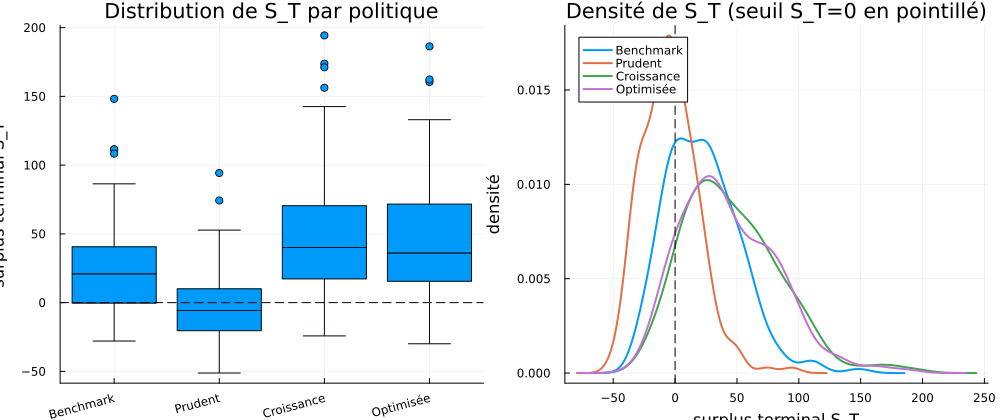

In [17]:
# === Graphiques : distributions de surplus terminal par politique ===
names = [n for (n, _) in policy_st]
idx   = Dict(n => i for (i, n) in enumerate(names))
labels = String[]; vals = Float64[]
for (name, ST) in policy_st
    append!(labels, fill(name, length(ST))); append!(vals, ST)
end
xpos = [idx[l] for l in labels]

p1 = boxplot(xpos, vals; legend=false, xticks=(1:length(names), names), xrotation=15,
             ylabel="surplus terminal S_T", title="Distribution de S_T par politique")
hline!(p1, [0.0]; ls=:dash, color=:black)

p2 = plot(; xlabel="surplus terminal S_T", ylabel="densité",
          title="Densité de S_T (seuil S_T=0 en pointillé)", legend=:topleft)
for (name, ST) in policy_st
    density!(p2, ST; label=name, lw=2)
end
vline!(p2, [0.0]; ls=:dash, color=:black, label="")

plt = plot(p1, p2; layout=(1,2), size=(1000,420))
savefig(plt, "comparaison_benchmarks.png")   # figure du rapport (§ Résultats)
plt


In [18]:
# === Stress hors échantillon : mauvaise spécification (réalité sous drift sobre) ===
# La politique optimisée CONSERVE ses croyances de la fenêtre : décision t=0 = racine du
# cas de base (w0), sous-arbres construits avec mu_a ESTIMÉ, ré-ancrage de delta au tau*
# de chaque sous-arbre — comme dans l'évaluation ci-dessus (base_seed=5000). Seule la
# RÉALITÉ change : trajectoires simulées sous drift sobre (log 5 % sur XIC et VFV,
# Sigma inchangée), graine dédiée 998. Test « la sécurité est-elle empruntée à la fenêtre ? ».
mu_sob_p5 = copy(mu_a)
for i in (1, 4); mu_sob_p5[i] = min(mu_a[i], 0.05); end
R_s, G_s = simulate_paths(N_PATHS, T, mu_sob_p5, Sigma_a, G_MEAN, G_SD; seed=998)

rows = NamedTuple[]
for (name, w) in baselines
    r = roll_fixedmix(w, R_s, G_s, Fstream, T, A0, L0, NA)
    push!(rows, (politique=name, S_moyen=round(mean(r.ST), digits=3),
                 CSaR=round(empirical_csar(r.ST, pw, GAMMA), digits=3),
                 P_sousfin=round(100*mean(r.ST .< 0), digits=1),
                 P_chemin=round(100*mean(r.minFR .< 1), digits=1),
                 minFR_moy=round(mean(r.minFR), digits=3)))
end
r_opt_s = roll_optimized(w0, R_s, G_s, Fstream, T, mu_a, Sigma_a, G_MEAN, G_SD;
                         na=NA, w_lower=W_LOWER, w_upper=W_UPPER, lambda=LAMBDA_BASE,
                         gamma=GAMMA, A0=A0, L0=L0, b_eval=B_EVAL, base_seed=5000)
push!(rows, (politique="Optimisée (multi-étapes)", S_moyen=round(mean(r_opt_s.ST), digits=3),
             CSaR=round(empirical_csar(r_opt_s.ST, pw, GAMMA), digits=3),
             P_sousfin=round(100*mean(r_opt_s.ST .< 0), digits=1),
             P_chemin=round(100*mean(r_opt_s.minFR .< 1), digits=1),
             minFR_moy=round(mean(r_opt_s.minFR), digits=3)))
df_stress = DataFrame(rows)
show(stdout, MIME"text/plain"(), df_stress; allcols=true)
df_stress

  roll_optimized : 800 sous-problèmes résolus, 0 infaisable (ancrage vérifié partout).
4×6 DataFrame
 Row │ politique                 S_moyen  CSaR     P_sousfin  P_chemin  minFR_moy 
     │ String                    Float64  Float64  Float64    Float64   Float64   
─────┼────────────────────────────────────────────────────────────────────────────
   1 │ Benchmark                 -11.555  -50.964       74.5      82.5      0.882
   2 │ Prudent                   -18.012  -55.987       83.5      90.0      0.853
   3 │ Croissance                 -6.208  -50.043       63.0      75.5      0.899
   4 │ Optimisée (multi-étapes)   -6.999  -50.511       64.5      77.0      0.896

Row,politique,S_moyen,CSaR,P_sousfin,P_chemin,minFR_moy
,String,Float64,Float64,Float64,Float64,Float64
1,Benchmark,-11.555,-50.964,74.5,82.5,0.882
2,Prudent,-18.012,-55.987,83.5,90.0,0.853
3,Croissance,-6.208,-50.043,63.0,75.5,0.899
4,Optimisée (multi-étapes),-6.999,-50.511,64.5,77.0,0.896


## Phase 6 — Analyses économiques

Frontière $\lambda$, balayage $\delta$ (frontière de faisabilité $\tau^\star$), grille $FR_0$, sensibilité à $\mu$ (part du surplus empruntée au marché haussier), sensibilité à la pente de $F_t$, allocation selon le ratio de capitalisation aux nœuds intermédiaires, plancher $\tau^\star$ conditionnel vs inconditionnel (cohérence temporelle), et utilité des ICC sous révision des croyances (h).


In [19]:
# === (a) Frontière lambda ===
lambda_grid = [0.0, 0.5, 1.0, 2.0, 5.0]
rows = NamedTuple[]
for lam in lambda_grid
    r = solve_alm(tree, Fstream; lambda=lam, gamma=GAMMA, na=NA,
                  w_lower=W_LOWER, w_upper=W_UPPER, delta=DELTA_BASE, A0=A0)
    w = root_weights(r, Fstream, NA); frl = fr_stats(r, tree)
    Sl = [r.A[n]-tree.L[n] for n in tree.leaves]; pl = [tree.prob[n] for n in tree.leaves]
    csar_ep = empirical_csar(Sl, pl, GAMMA)   # ex post : à lambda=0, eta du LP est arbitraire
    push!(rows, (lambda=lam, E_ST=round(r.ES, digits=3), CSaR=round(csar_ep, digits=3), P_FRunder=round(100*frl.p_under, digits=1),
                 XIC=round(w[1], digits=3), XLB=round(w[2], digits=3), XRB=round(w[3], digits=3), VFV=round(w[4], digits=3), CGL=round(w[5], digits=3)))
end
DataFrame(rows)


Row,lambda,E_ST,CSaR,P_FRunder,XIC,XLB,XRB,VFV,CGL
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.0,56.618,-16.397,7.0,0.3,0.15,0.05,0.4,0.1
2,0.5,56.314,-14.645,7.1,0.4,0.15,0.05,0.3,0.1
3,1.0,56.153,-14.428,7.2,0.4,0.15,0.05,0.3,0.1
4,2.0,55.993,-14.32,7.3,0.4,0.15,0.05,0.3,0.1
5,5.0,55.368,-14.12,7.4,0.4,0.15,0.05,0.3,0.1


In [20]:
# === (b) Balayage delta : frontière de faisabilité tau* ===
# Arrondi PAR EXCÈS (cf. remarque « arrondi » du rapport) : un round au plus proche
# peut faire passer le point ratio=1.0 sous tau* et le rendre infaisable à tort.
# Le point ratio=1.0 est pris à tau* EXACT (sans arrondi) : c'est la frontière,
# le seul endroit où la contrainte est active (duals > 0). Le point round(tau*)
# (arrondi au plus proche) est ajouté pour exhiber l'infaisabilité de l'arrondi
# fautif — illustration numérique de la remarque « arrondi » du rapport.
delta_grid = vcat(tau_star, round(tau_star; digits=4),
                  ceil.([0.80, 0.95, 1.10, 1.30, 1.60, 2.00] .* tau_star; digits=4))
rows = NamedTuple[]
for d in delta_grid
    r = solve_alm(tree, Fstream; lambda=LAMBDA_BASE, gamma=GAMMA, na=NA,
                  w_lower=W_LOWER, w_upper=W_UPPER, delta=d, A0=A0)
    if r.feasible
        frd  = fr_stats(r, tree)
        dabs = isempty(r.icc_dual) ? 0.0 : sum(abs, r.icc_dual)
        push!(rows, (delta=round(d, digits=5), ratio_sur_tau=round(d/tau_star, digits=3), faisable=true,
                     E_ST=round(r.ES, digits=3), CSaR=round(r.csar, digits=3), dual_tot=round(dabs, digits=3),
                     P_FRunder=round(100*frd.p_under, digits=1)))
    else
        push!(rows, (delta=round(d, digits=5), ratio_sur_tau=round(d/tau_star, digits=3), faisable=false,
                     E_ST=NaN, CSaR=NaN, dual_tot=NaN, P_FRunder=NaN))
    end
end
DataFrame(rows)


Row,delta,ratio_sur_tau,faisable,E_ST,CSaR,dual_tot,P_FRunder
,Float64,Float64,Bool,Float64,Float64,Float64,Float64
1,0.01083,1.0,true,55.812,-14.393,57.716,7.4
2,0.0108,0.997,false,NaN,NaN,NaN,NaN
3,0.0087,0.804,false,NaN,NaN,NaN,NaN
4,0.0103,0.951,false,NaN,NaN,NaN,NaN
5,0.012,1.108,true,56.153,-14.428,0.0,7.2
6,0.0141,1.302,true,56.153,-14.428,0.0,7.2
7,0.0174,1.607,true,56.153,-14.428,0.0,7.2
8,0.0217,2.004,true,56.153,-14.428,0.0,7.2


In [21]:
# === (c) Grille du ratio de capitalisation initial FR_0 ===
fr0_grid = [0.90, 1.00, 1.10]
rows = NamedTuple[]
for fr0 in fr0_grid
    A0v = fr0 * L0
    τ   = min_tau_uniform(tree, Fstream; na=NA, w_lower=W_LOWER, w_upper=W_UPPER, A0=A0v)
    r   = solve_alm(tree, Fstream; lambda=LAMBDA_BASE, gamma=GAMMA, na=NA,
                    w_lower=W_LOWER, w_upper=W_UPPER, delta=ceil(1.10*τ; digits=4), A0=A0v)
    w   = [r.x[1,i] / (r.A[1]-Fstream[1]) for i in 1:NA]
    frv = fr_stats(r, tree)
    push!(rows, (FR0=fr0, tau_star=round(τ, digits=4), E_ST=round(r.ES, digits=3), CSaR=round(r.csar, digits=3),
                 P_FRunder=round(100*frv.p_under, digits=1), XIC=round(w[1], digits=3), VFV=round(w[4], digits=3), CGL=round(w[5], digits=3)))
end
DataFrame(rows)


Row,FR0,tau_star,E_ST,CSaR,P_FRunder,XIC,VFV,CGL
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.9,0.0402,36.522,-26.917,16.5,0.4,0.3,0.1
2,1.0,0.0108,56.153,-14.428,7.2,0.4,0.3,0.1
3,1.1,0.0022,75.79,-1.971,2.5,0.4,0.3,0.1


In [22]:
# === (d) Sensibilité à mu : part du surplus empruntée au marché haussier 2013–2026 ===
mu_sober = copy(mu_a)
for i in (1, 4); mu_sober[i] = min(mu_a[i], 0.05); end   # actions CA & US ramenées à un drift sobre (log 5%)
tree_s = build_tree(branches=BRANCHES, mu_a=mu_sober, Sigma_a=Sigma_a,
                    g_mean=G_MEAN, g_sd=G_SD, A0=A0, L0=L0, na=NA, seed=SEED0)
Fs, _  = disbursement_stream(tree_s, PHI, T)
τs     = min_tau_uniform(tree_s, Fs; na=NA, w_lower=W_LOWER, w_upper=W_UPPER, A0=A0)
rs     = solve_alm(tree_s, Fs; lambda=LAMBDA_BASE, gamma=GAMMA, na=NA,
                   w_lower=W_LOWER, w_upper=W_UPPER, delta=ceil(1.10*τs; digits=4), A0=A0)
frb = fr_stats(res, tree); frsv = fr_stats(rs, tree_s)

@printf("Drift actions (log) : base XIC=%.3f / VFV=%.3f   ->   sobre = 0.050 (les deux)\n", mu_a[1], mu_a[4])
@printf("%-14s %12s %12s\n", "", "base", "sobre")
@printf("  E[S_T]      %12.2f %12.2f\n", res.ES, rs.ES)
@printf("  CSaR        %12.2f %12.2f\n", res.csar, rs.csar)
@printf("  P(FR<1)     %11.1f%% %11.1f%%\n", 100*frb.p_under, 100*frsv.p_under)
@printf("  tau*        %12.4f %12.4f\n", tau_star, τs)
println("\nLa hausse de P(FR<1) sous drift sobre = part de sécurité empruntée au marché 2013–2026.")


Drift actions (log) : base XIC=0.106 / VFV=0.163   ->   sobre = 0.050 (les deux)
                       base        sobre
  E[S_T]             56.15        10.60
  CSaR              -14.43       -38.92
  P(FR<1)             7.2%        40.1%
  tau*              0.0108       0.0423

La hausse de P(FR<1) sous drift sobre = part de sécurité empruntée au marché 2013–2026.


In [23]:
# === (e) Sensibilité à la pente du décaissement F_t ===
profils = [("plat 2%", fill(0.02, T)),
           ("2→4%",    collect(range(0.02, 0.04, length=T))),
           ("3→6%",    collect(range(0.03, 0.06, length=T)))]
rows = NamedTuple[]
for (name, phi) in profils
    Fp, _ = disbursement_stream(tree, phi, T)
    τ = min_tau_uniform(tree, Fp; na=NA, w_lower=W_LOWER, w_upper=W_UPPER, A0=A0)
    r = solve_alm(tree, Fp; lambda=LAMBDA_BASE, gamma=GAMMA, na=NA,
                  w_lower=W_LOWER, w_upper=W_UPPER, delta=ceil(1.10*τ; digits=4), A0=A0)
    frp = fr_stats(r, tree)
    push!(rows, (profil_F=name, tau_star=round(τ, digits=4), E_ST=round(r.ES, digits=3),
                 CSaR=round(r.csar, digits=3), P_FRunder=round(100*frp.p_under, digits=1)))
end
DataFrame(rows)


Row,profil_F,tau_star,E_ST,CSaR,P_FRunder
,String,Float64,Float64,Float64,Float64
1,plat 2%,0.0102,63.226,-8.379,3.9
2,2→4%,0.0108,56.153,-14.428,7.2
3,3→6%,0.0138,44.723,-23.595,12.9


In [24]:
# === (f) Allocation selon le ratio de capitalisation aux nœuds intermédiaires (recours) ===
depth_show = 2
nodes_d = [n for n in tree.nonleaf if tree.depth[n]==depth_show]
FR_d = [res.A[n]/tree.L[n] for n in nodes_d]
wEq  = [(res.x[n,1]+res.x[n,4])/(res.A[n]-Fstream[depth_show+1]) for n in nodes_d]   # actions = XIC+VFV
wOr  = [ res.x[n,5]/(res.A[n]-Fstream[depth_show+1]) for n in nodes_d]               # or

@printf("Profondeur t=%d : %d nœuds\n", depth_show, length(nodes_d))
@printf("Corrélation (FR, part actions XIC+VFV) : %.3f\n", cor(FR_d, wEq))
@printf("Corrélation (FR, part or CGL)          : %.3f\n", cor(FR_d, wOr))
qs = quantile(FR_d, [0.0,0.25,0.5,0.75,1.0])
println("FR (quartiles) et allocation moyenne associée :")
for b in 1:4
    sel = [k for k in eachindex(nodes_d) if qs[b] <= FR_d[k] <= qs[b+1]]
    @printf("  FR ∈ [%.2f, %.2f] : actions=%.3f  or=%.3f\n",
            qs[b], qs[b+1], mean(wEq[sel]), mean(wOr[sel]))
end


Profondeur t=2 : 50 nœuds
Corrélation (FR, part actions XIC+VFV) : 0.243
Corrélation (FR, part or CGL)          : -0.235
FR (quartiles) et allocation moyenne associée :
  FR ∈ [0.85, 1.08] : actions=0.681  or=0.054
  FR ∈ [1.08, 1.21] : actions=0.750  or=0.050
  FR ∈ [1.21, 1.37] : actions=0.738  or=0.033
  FR ∈ [1.37, 1.56] : actions=0.769  or=0.031


In [25]:
# === (g) Plancher tau* : conditionnel vs inconditionnel (cohérence temporelle) ===
"Plus petite tolérance tau d'une ICC CONDITIONNELLE (état par état) rendant le problème réalisable."
function min_tau_conditional(tree, Fstream; na, w_lower, w_upper, A0, period_offset=0)
    m = Model(HiGHS.Optimizer); set_silent(m)
    nodes = 1:tree.n_nodes
    @variable(m, x[tree.nonleaf, 1:na] >= 0)
    @variable(m, A[nodes] >= 0)
    @variable(m, D[nodes] >= 0)
    @variable(m, tau >= 0)
    @constraint(m, A[1] == A0)
    for n in 2:tree.n_nodes
        par = tree.parent[n]
        @constraint(m, A[n] == sum(x[par,i]*(1+tree.ret[n][i]) for i in 1:na))
    end
    for n in tree.nonleaf
        Fn = Fstream[period_offset + tree.depth[n] + 1]
        @constraint(m, sum(x[n,i] for i in 1:na) == A[n] - Fn)
        for i in 1:na
            @constraint(m, x[n,i] >= w_lower[i]*(A[n]-Fn))
            @constraint(m, x[n,i] <= w_upper[i]*(A[n]-Fn))
        end
    end
    for n in nodes; @constraint(m, D[n] >= tree.L[n] - A[n]); end
    Tloc = maximum(tree.depth)
    for mnode in tree.nonleaf
        tree.depth[mnode] <= Tloc-2 || continue
        ch = tree.children[mnode]
        @constraint(m, sum(tree.prob[c]*D[c] for c in ch) <= tau*sum(tree.prob[c]*tree.L[c] for c in ch))
    end
    @objective(m, Min, tau)
    optimize!(m)
    return objective_value(m)
end

tau_unc = min_tau_uniform(tree, Fstream; na=NA, w_lower=W_LOWER, w_upper=W_UPPER, A0=A0)
tau_con = min_tau_conditional(tree, Fstream; na=NA, w_lower=W_LOWER, w_upper=W_UPPER, A0=A0)
@printf("Plancher de solvabilité (actif fermé) :\n")
@printf("  tau* inconditionnel (ex ante, vue racine) : %.4f\n", tau_unc)
@printf("  tau* conditionnel  (état par état)        : %.4f\n", tau_con)
@printf("  écart = prix de la cohérence temporelle   : %.4f\n", tau_con - tau_unc)
println("tau*_cond > tau*_uncond : sans cotisations, garantir la solvabilité à CHAQUE nœud exige")
println("une tolérance bien plus élevée — l'argument économique pour les cotisations de redressement.")


Plancher de solvabilité (actif fermé) :
  tau* inconditionnel (ex ante, vue racine) : 0.0108
  tau* conditionnel  (état par état)        : 0.2139
  écart = prix de la cohérence temporelle   : 0.2030
tau*_cond > tau*_uncond : sans cotisations, garantir la solvabilité à CHAQUE nœud exige
une tolérance bien plus élevée — l'argument économique pour les cotisations de redressement.


### (h) Utilité des ICC : une contrainte de faisabilité, pas un prix marginal

Au cas de base, les duals ICC sont nuls : l'objectif CSaR ($\lambda=1$) pousse déjà le manque de chemin contre son minimum minimax, si bien que le profil libre colle à $\tau^*$ et que $\delta=1{,}10\,\tau^*$ reste lâche. L'expérience fait glisser le drift actions de sa valeur estimée ($\alpha=1$) vers un drift sobre de 5 % ($\alpha=0$), à $\delta$ **fixé** au cas de base. Le résultat est tranché : l'ICC ne s'active presque jamais *marginalement* — elle **bascule** de dormante à infaisable dès une révision modeste des croyances (le plancher $\tau^*_\alpha$ franchit $\delta$). Trois lectures : (i) l'utilité des ICC dans ce problème est de *révéler la frontière de solvabilité* — c'est $\tau^*$, objet dérivé de l'ICC par le minimax, qui porte le contenu économique ; (ii) la marge de 10 % sur $\tau^*$ se réinterprète comme un budget de robustesse aux croyances, consommé par une révision de quelques dizaines de points de base du drift ; (iii) le pendant *contraintes* de la sensibilité à $\mu$ (d) : la solvabilité apparente est empruntée à la fenêtre d'estimation, et l'ICC est le composant qui l'encaisse en premier. Les duals non nuls, eux, s'observent exactement sur la frontière ($\delta=\tau^*$, balayage (b)).

In [26]:
# === (h) Utilité des ICC : activation sous révision des croyances ===
# delta est FIXÉ à sa valeur du cas de base ; on fait glisser le drift actions vers le sobre.
alpha_grid = [1.0, 0.95, 0.90, 0.85, 0.8, 0.6, 0.4, 0.2, 0.0]   # 1 = fenêtre 2013-2026, 0 = drift sobre (log 5 %)
rows = NamedTuple[]
for a in alpha_grid
    mu_m = copy(mu_a)
    for i in (1, 4); mu_m[i] = a*mu_a[i] + (1-a)*0.05; end
    tree_m = build_tree(branches=BRANCHES, mu_a=mu_m, Sigma_a=Sigma_a,
                        g_mean=G_MEAN, g_sd=G_SD, A0=A0, L0=L0, na=NA, seed=SEED0)
    Fm, _ = disbursement_stream(tree_m, PHI, T)
    rfree = solve_alm(tree_m, Fm; lambda=LAMBDA_BASE, gamma=GAMMA, na=NA,
                      w_lower=W_LOWER, w_upper=W_UPPER, delta=nothing, A0=A0)
    tau_m = min_tau_uniform(tree_m, Fm; na=NA, w_lower=W_LOWER, w_upper=W_UPPER, A0=A0)
    rc = solve_alm(tree_m, Fm; lambda=LAMBDA_BASE, gamma=GAMMA, na=NA,
                   w_lower=W_LOWER, w_upper=W_UPPER, delta=DELTA_BASE, A0=A0)
    mfree = round(maximum(shortage_profile(rfree, tree_m, T)), digits=4)
    if rc.feasible
        push!(rows, (alpha=a, mu_XIC=round(mu_m[1], digits=3), mu_VFV=round(mu_m[4], digits=3),
                     manque_libre=mfree, tau_star_m=round(tau_m, digits=4), faisable=true,
                     dual_tot=round(sum(abs, rc.icc_dual), digits=3), E_ST=round(rc.ES, digits=2)))
    else
        push!(rows, (alpha=a, mu_XIC=round(mu_m[1], digits=3), mu_VFV=round(mu_m[4], digits=3),
                     manque_libre=mfree, tau_star_m=round(tau_m, digits=4), faisable=false,
                     dual_tot=NaN, E_ST=NaN))
    end
end
@printf("delta FIXE = %.4f (= 1.10*tau* du cas de base)\n", DELTA_BASE)
DataFrame(rows)

delta FIXE = 0.0120 (= 1.10*tau* du cas de base)


Row,alpha,mu_XIC,mu_VFV,manque_libre,tau_star_m,faisable,dual_tot,E_ST
,Float64,Float64,Float64,Float64,Float64,Bool,Float64,Float64
1,1.0,0.106,0.163,0.0109,0.0108,true,0.0,56.15
2,0.95,0.103,0.157,0.0116,0.0115,true,0.0,53.24
3,0.9,0.1,0.152,0.0122,0.0121,false,NaN,NaN
4,0.85,0.097,0.146,0.013,0.0128,false,NaN,NaN
5,0.8,0.095,0.14,0.0138,0.0136,false,NaN,NaN
6,0.6,0.083,0.118,0.0182,0.0167,false,NaN,NaN
7,0.4,0.072,0.095,0.0267,0.0239,false,NaN,NaN
8,0.2,0.061,0.073,0.0358,0.0325,false,NaN,NaN
9,0.0,0.05,0.05,0.0463,0.0423,false,NaN,NaN


## Limites et extensions

**Limites assumées** : passif exogène et indépendant des rendements ($g\perp r$) ; CSaR terminale statique (non imbriquée) ; log-rendements i.i.d. gaussiens ; risque de change non couvert (VFV ; CGL couvert) ; exposition actions concentrée (XIC↔VFV) ; or sans revenu (borné en satellite) ; moyennes $\mu$ estimées sur une fenêtre courte et haussière (fragiles — cf. sensibilité $\mu$ et instabilité du profil de manque) ; actif fermé (plancher de solvabilité $\tau^\star$ élevé).

**Extensions** : cotisations $c_n$ + lissage (modèle institutionnel complet) ; ICC conditionnelle élastique ; couplage taux–passif (couverture de duration émergente) ; CVaR imbriquée / SDDP (cohérence temporelle, horizons longs) ; bootstrap par blocs comme générateur ; appariement de moments / Cornish–Fisher pour les queues.
